# Chemical Data ML Project

This notebook trains supervised models from `chem_excel_final.xlsx`.

- Absorbance regression from volume and concentration
- Colour prediction as RGB regression, converted back to HEX
- A second variant of both models trained **without volume** (concentration only)
- A **multi-model experiment** comparing several regressors with and without volume

The workbook contains a few incomplete rows and one obvious absorbance outlier (`52`). The notebook removes incomplete rows and filters that outlier before training.


In [ ]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from openpyxl import load_workbook
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [19]:
DATA_PATH = Path("chem_excel_final.xlsx")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH.resolve()}")

raw = pd.read_excel(DATA_PATH, engine="openpyxl")
raw.columns = ["blank", "name", "conc", "wl_nm", "abs", "photos", "hex", "r", "g", "b", "hsl"]
raw.head()

,blank,name,conc,wl_nm,abs,photos,hex,r,g,b,hsl
0,NaN,5ml,0.2,640.0,0.08,Picture,NaN,NaN,NaN,NaN,NaN
1,NaN,5ml,0.4,640.0,0.14,Picture,NaN,NaN,NaN,NaN,NaN
2,NaN,5ml,0.6,640.0,0.21,NaN,#121A1E,18.0,26.0,30.0,"hsl(199, 25%, 9%)"
3,NaN,5ml,0.8,640.0,52.00,NaN,#081018,8.0,16.0,24.0,"hsl(210, 50%, 6%)"
4,NaN,5ml,1.0,640.0,0.33,NaN,#89BBB8,137.0,187.0,184.0,"hsl(176, 26%, 63%)"


In [20]:
df = raw.copy()
df["volume_label"] = df["name"].astype(str).str.strip()
df["volume_ml"] = df["volume_label"].str.extract(r"(\d+(?:\.\d+)?)").astype(float)
df["conc"] = pd.to_numeric(df["conc"], errors="coerce")
df["abs"] = pd.to_numeric(df["abs"], errors="coerce")
for col in ["r", "g", "b"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["hex"] = df["hex"].astype(str).str.upper()
valid_hex = df["hex"].str.match(r"^#[0-9A-F]{6}$", na=False)

clean = df.loc[
    df["volume_ml"].notna()
    & df["conc"].notna()
    & df["abs"].notna()
    & valid_hex
    & df[["r", "g", "b"]].notna().all(axis=1)
].copy()

# Remove the obvious absorbance typo/outlier so the regression is not dominated by one bad row.
clean = clean.loc[clean["abs"] <= 10].copy()
clean.reset_index(drop=True, inplace=True)
clean[["volume_label", "volume_ml", "conc", "abs", "hex", "r", "g", "b"]].head(10)

,volume_label,volume_ml,conc,abs,hex,r,g,b
0,5ml,5.0,0.6,0.21,#121A1E,18.0,26.0,30.0
1,5ml,5.0,1.0,0.33,#89BBB8,137.0,187.0,184.0
2,5ml,5.0,1.2,0.40,#73B4BA,115.0,180.0,186.0
3,5ml,5.0,1.4,0.48,#72B9BA,114.0,185.0,186.0
4,5ml,5.0,1.6,0.53,#5EB8C2,94.0,184.0,194.0
5,5ml,5.0,1.8,0.56,#5ABAC3,90.0,186.0,195.0
6,5ml,5.0,2.0,0.63,#54B4BC,84.0,180.0,188.0
7,5ml,5.0,2.2,0.69,#3BB5C7,59.0,181.0,199.0
8,5ml,5.0,2.4,0.74,#36B4C4,54.0,180.0,196.0
9,5ml,5.0,2.6,0.82,#29A9BB,41.0,169.0,187.0


In [21]:
print(f"Raw rows: {len(raw)}")
print(f"Usable rows after cleaning: {len(clean)}")
print("Volumes present:", sorted(clean["volume_label"].unique()))
print("Absorbance range:", float(clean["abs"].min()), "to", float(clean["abs"].max()))
print()
display(clean.groupby("volume_label")["conc"].agg(["count", "min", "max"]))

Raw rows: 101
Usable rows after cleaning: 90
Volumes present: ['1ml', '2ml', '3ml', '4ml', '5ml']
Absorbance range: 0.09 to 2.0



,count,min,max
volume_label,,,
1ml,10,1.00,10.00
2ml,12,0.50,6.00
3ml,20,0.30,6.00
4ml,19,0.25,4.75
5ml,29,0.60,6.40


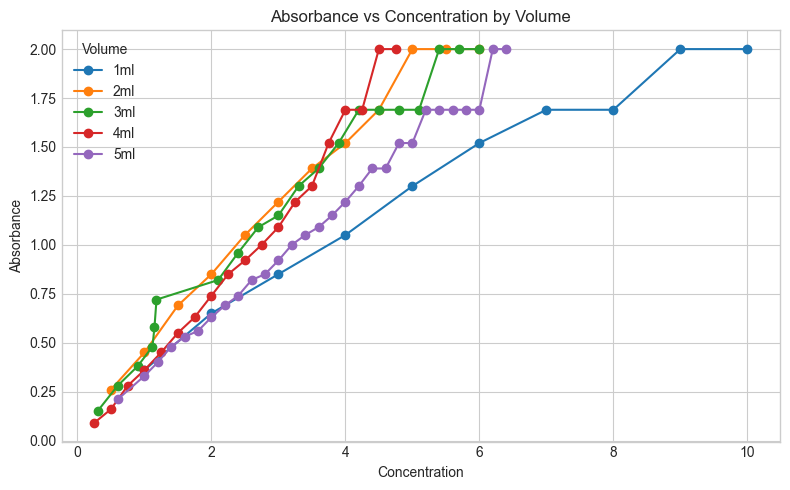

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, group in clean.groupby("volume_label"):
    ax.plot(group["conc"], group["abs"], marker="o", linewidth=1.5, label=label)
ax.set_title("Absorbance vs Concentration by Volume")
ax.set_xlabel("Concentration")
ax.set_ylabel("Absorbance")
ax.legend(title="Volume")
plt.tight_layout()
plt.show()

## Correlation heatmap

Pearson correlation between **absorbance**, **concentration**, and **volume** on the cleaned data.


,Absorbance,Concentration,Volume (mL)
Absorbance,1.000,0.914,-0.139
Concentration,0.914,1.000,-0.192
Volume (mL),-0.139,-0.192,1.000


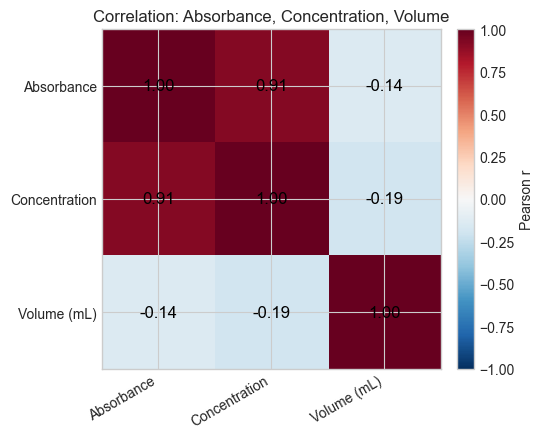

Saved: artifacts\correlation_heatmap.png


In [37]:
corr_cols = ["abs", "conc", "volume_ml"]
corr = clean[corr_cols].corr(method="pearson")
corr = corr.rename(index={"abs": "Absorbance", "conc": "Concentration", "volume_ml": "Volume (mL)"},
                   columns={"abs": "Absorbance", "conc": "Concentration", "volume_ml": "Volume (mL)"})

display(corr.round(3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=30, ha="right")
ax.set_yticklabels(corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=12)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
ax.set_title("Correlation: Absorbance, Concentration, Volume")
fig.tight_layout()

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
fig.savefig(ARTIFACT_DIR / "correlation_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", ARTIFACT_DIR / "correlation_heatmap.png")


In [23]:
feature_cols = ["volume_ml", "conc"]
X = clean[feature_cols]
y_abs = clean["abs"]
y_rgb = clean[["r", "g", "b"]]

X_train, X_test, y_abs_train, y_abs_test, y_rgb_train, y_rgb_test = train_test_split(
    X, y_abs, y_rgb, test_size=0.2, random_state=42
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
X_train.head()

Train rows: 72
Test rows: 18


,volume_ml,conc
49,3.0,0.6
62,3.0,4.5
73,2.0,3.0
69,2.0,1.0
76,2.0,4.5


In [24]:
abs_model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    min_samples_leaf=2,
)
abs_model.fit(X_train, y_abs_train)
abs_pred = abs_model.predict(X_test)

abs_mae = mean_absolute_error(y_abs_test, abs_pred)
abs_rmse = np.sqrt(mean_squared_error(y_abs_test, abs_pred))
abs_r2 = r2_score(y_abs_test, abs_pred)

print("Absorbance model")
print("MAE :", round(abs_mae, 4))
print("RMSE:", round(abs_rmse, 4))
print("R2  :", round(abs_r2, 4))

Absorbance model
MAE : 0.1106
RMSE: 0.1286
R2  : 0.9385


In [25]:
color_feature_cols = ["volume_ml", "conc", "abs_pred"]
train_abs_pred = abs_model.predict(X_train)
test_abs_pred = abs_model.predict(X_test)

X_rgb_train = X_train.copy().assign(abs_pred=train_abs_pred)
X_rgb_test = X_test.copy().assign(abs_pred=test_abs_pred)

rgb_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        min_samples_leaf=2,
    )
)
rgb_model.fit(X_rgb_train, y_rgb_train)
rgb_pred = rgb_model.predict(X_rgb_test)

rgb_mae = mean_absolute_error(y_rgb_test, rgb_pred)
rgb_mae_channels = mean_absolute_error(y_rgb_test, rgb_pred, multioutput="raw_values")
rgb_rmse = np.sqrt(mean_squared_error(y_rgb_test, rgb_pred))
rgb_r2 = r2_score(y_rgb_test, rgb_pred)
rgb_r2_channels = r2_score(y_rgb_test, rgb_pred, multioutput="raw_values")

print("Colour model")
print("MAE overall:", round(rgb_mae, 4))
print("MAE R/G/B :", [round(float(x), 4) for x in rgb_mae_channels])
print("RMSE overall:", round(rgb_rmse, 4))
print("R2 overall:", round(rgb_r2, 4))
print("R2 R/G/B   :", [round(float(x), 4) for x in rgb_r2_channels])

Colour model
MAE overall: 17.0314
MAE R/G/B : [21.0414, 14.9588, 15.094]
RMSE overall: 32.6486
R2 overall: 0.2818
R2 R/G/B   : [-0.0176, 0.292, 0.5711]


In [26]:
def rgb_to_hex(rgb_values):
    r, g, b = (int(np.clip(round(value), 0, 255)) for value in rgb_values)
    return f"#{r:02X}{g:02X}{b:02X}"


def predict_sample(volume_ml, concentration):
    sample = pd.DataFrame({"volume_ml": [volume_ml], "conc": [concentration]})
    predicted_abs = float(abs_model.predict(sample)[0])
    sample_color = sample.assign(abs_pred=[predicted_abs])
    predicted_rgb = np.rint(np.clip(rgb_model.predict(sample_color)[0], 0, 255)).astype(int)
    predicted_hex = rgb_to_hex(predicted_rgb)
    return {
        "volume_ml": float(volume_ml),
        "concentration": float(concentration),
        "predicted_absorbance": predicted_abs,
        "predicted_rgb": tuple(int(v) for v in predicted_rgb),
        "predicted_hex": predicted_hex,
    }

example = predict_sample(3, 1.5)
example

{'volume_ml': 3.0,
 'concentration': 1.5,
 'predicted_absorbance': 0.5574097619047623,
 'predicted_rgb': (99, 163, 192),
 'predicted_hex': '#63A3C0'}

In [27]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(abs_model, ARTIFACT_DIR / "absorbance_model.joblib")
joblib.dump(rgb_model, ARTIFACT_DIR / "colour_model_rgb.joblib")
joblib.dump({
    "abs_feature_cols": feature_cols,
    "color_feature_cols": color_feature_cols,
    "clean_rows": len(clean),
    "volume_labels": sorted(clean["volume_label"].unique().tolist()),
}, ARTIFACT_DIR / "model_metadata.joblib")

print("Saved models to:", ARTIFACT_DIR.resolve())

Saved models to: C:\Users\Jyothi\Chemistry\artifacts


In [28]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(abs_model, ARTIFACT_DIR / "absorbance_model.joblib")
joblib.dump(rgb_model, ARTIFACT_DIR / "colour_model_rgb.joblib")
joblib.dump({
    "feature_cols": feature_cols,
    "clean_rows": len(clean),
    "volume_labels": sorted(clean["volume_label"].unique().tolist()),
}, ARTIFACT_DIR / "model_metadata.joblib")

print("Saved models to:", ARTIFACT_DIR.resolve())

Saved models to: C:\Users\Jyothi\Chemistry\artifacts


## Model variant: concentration only (no volume)

Train a second pair of models that ignore `volume_ml` and use only `conc`.

- Absorbance: \(f(conc) \rightarrow abs\)
- Colour: \(g(conc, predicted\_abs) \rightarrow (R,G,B)\)

This lets you compare how much volume contributes versus concentration alone. Artifacts are saved separately so the original volume+concentration models are unchanged.


In [29]:
# Same train/test split indices as the volume+conc models, but features = concentration only
feature_cols_no_vol = ["conc"]
X_nv = clean[feature_cols_no_vol]

X_train_nv, X_test_nv, y_abs_train_nv, y_abs_test_nv, y_rgb_train_nv, y_rgb_test_nv = train_test_split(
    X_nv, y_abs, y_rgb, test_size=0.2, random_state=42
)

print("No-volume train rows:", len(X_train_nv))
print("No-volume test rows:", len(X_test_nv))
X_train_nv.head()


No-volume train rows: 72
No-volume test rows: 18


,conc
49,0.6
62,4.5
73,3.0
69,1.0
76,4.5


In [30]:
abs_model_no_vol = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    min_samples_leaf=2,
)
abs_model_no_vol.fit(X_train_nv, y_abs_train_nv)
abs_pred_nv = abs_model_no_vol.predict(X_test_nv)

abs_mae_nv = mean_absolute_error(y_abs_test_nv, abs_pred_nv)
abs_rmse_nv = np.sqrt(mean_squared_error(y_abs_test_nv, abs_pred_nv))
abs_r2_nv = r2_score(y_abs_test_nv, abs_pred_nv)

print("Absorbance model (no volume)")
print("MAE :", round(abs_mae_nv, 4))
print("RMSE:", round(abs_rmse_nv, 4))
print("R2  :", round(abs_r2_nv, 4))
print()
print("Compare to volume+conc absorbance model")
print("MAE :", round(abs_mae, 4), "->", round(abs_mae_nv, 4))
print("RMSE:", round(abs_rmse, 4), "->", round(abs_rmse_nv, 4))
print("R2  :", round(abs_r2, 4), "->", round(abs_r2_nv, 4))


Absorbance model (no volume)
MAE : 0.1437
RMSE: 0.1796
R2  : 0.8801

Compare to volume+conc absorbance model
MAE : 0.1106 -> 0.1437
RMSE: 0.1286 -> 0.1796
R2  : 0.9385 -> 0.8801


In [31]:
color_feature_cols_no_vol = ["conc", "abs_pred"]
train_abs_pred_nv = abs_model_no_vol.predict(X_train_nv)
test_abs_pred_nv = abs_model_no_vol.predict(X_test_nv)

X_rgb_train_nv = X_train_nv.copy().assign(abs_pred=train_abs_pred_nv)
X_rgb_test_nv = X_test_nv.copy().assign(abs_pred=test_abs_pred_nv)

rgb_model_no_vol = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        min_samples_leaf=2,
    )
)
rgb_model_no_vol.fit(X_rgb_train_nv, y_rgb_train_nv)
rgb_pred_nv = rgb_model_no_vol.predict(X_rgb_test_nv)

rgb_mae_nv = mean_absolute_error(y_rgb_test_nv, rgb_pred_nv)
rgb_mae_channels_nv = mean_absolute_error(y_rgb_test_nv, rgb_pred_nv, multioutput="raw_values")
rgb_rmse_nv = np.sqrt(mean_squared_error(y_rgb_test_nv, rgb_pred_nv))
rgb_r2_nv = r2_score(y_rgb_test_nv, rgb_pred_nv)
rgb_r2_channels_nv = r2_score(y_rgb_test_nv, rgb_pred_nv, multioutput="raw_values")

print("Colour model (no volume)")
print("MAE overall:", round(rgb_mae_nv, 4))
print("MAE R/G/B :", [round(float(x), 4) for x in rgb_mae_channels_nv])
print("RMSE overall:", round(rgb_rmse_nv, 4))
print("R2 overall:", round(rgb_r2_nv, 4))
print("R2 R/G/B   :", [round(float(x), 4) for x in rgb_r2_channels_nv])
print()
print("Compare to volume+conc colour model")
print("MAE :", round(rgb_mae, 4), "->", round(rgb_mae_nv, 4))
print("RMSE:", round(rgb_rmse, 4), "->", round(rgb_rmse_nv, 4))
print("R2  :", round(rgb_r2, 4), "->", round(rgb_r2_nv, 4))


Colour model (no volume)
MAE overall: 20.2191
MAE R/G/B : [24.2907, 16.7126, 19.6541]
RMSE overall: 35.6527
R2 overall: 0.1711
R2 R/G/B   : [-0.116, 0.2686, 0.3609]

Compare to volume+conc colour model
MAE : 17.0314 -> 20.2191
RMSE: 32.6486 -> 35.6527
R2  : 0.2818 -> 0.1711


## With volume vs without volume — metric comparison

Bar charts of test-set MAE, RMSE, and R² for both model variants (absorbance and colour).


,Model,Target,MAE,RMSE,R2
0,With volume,Absorbance,0.1106,0.1286,0.9385
1,Without volume,Absorbance,0.1437,0.1796,0.8801
2,With volume,Colour (RGB),17.0314,32.6486,0.2818
3,Without volume,Colour (RGB),20.2191,35.6527,0.1711


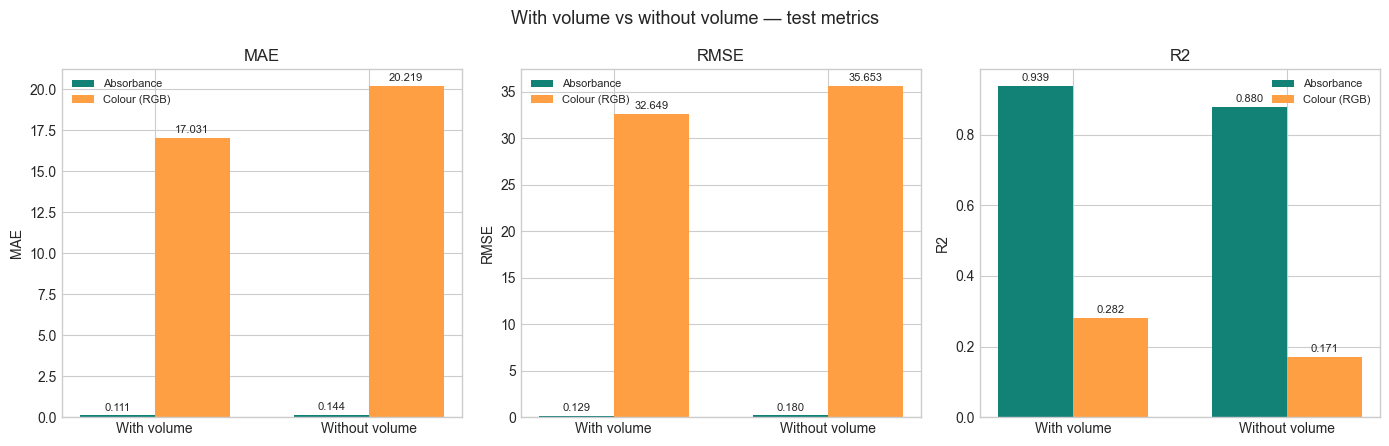

In [32]:
comparison = pd.DataFrame(
    {
        "Model": ["With volume", "Without volume", "With volume", "Without volume"],
        "Target": ["Absorbance", "Absorbance", "Colour (RGB)", "Colour (RGB)"],
        "MAE": [abs_mae, abs_mae_nv, rgb_mae, rgb_mae_nv],
        "RMSE": [abs_rmse, abs_rmse_nv, rgb_rmse, rgb_rmse_nv],
        "R2": [abs_r2, abs_r2_nv, rgb_r2, rgb_r2_nv],
    }
)
display(comparison.round(4))

metrics = ["MAE", "RMSE", "R2"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
x = np.arange(2)
width = 0.35

for ax, metric in zip(axes, metrics):
    abs_vals = comparison.loc[comparison["Target"] == "Absorbance", metric].to_numpy()
    rgb_vals = comparison.loc[comparison["Target"] == "Colour (RGB)", metric].to_numpy()
    bars1 = ax.bar(x - width / 2, abs_vals, width, label="Absorbance", color="#128277")
    bars2 = ax.bar(x + width / 2, rgb_vals, width, label="Colour (RGB)", color="#FF9F43")
    ax.set_xticks(x)
    ax.set_xticklabels(["With volume", "Without volume"])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.bar_label(bars1, fmt="%.3f", fontsize=8, padding=2)
    ax.bar_label(bars2, fmt="%.3f", fontsize=8, padding=2)
    ax.legend(fontsize=8)

fig.suptitle("With volume vs without volume — test metrics", fontsize=13)
fig.tight_layout()
plt.show()


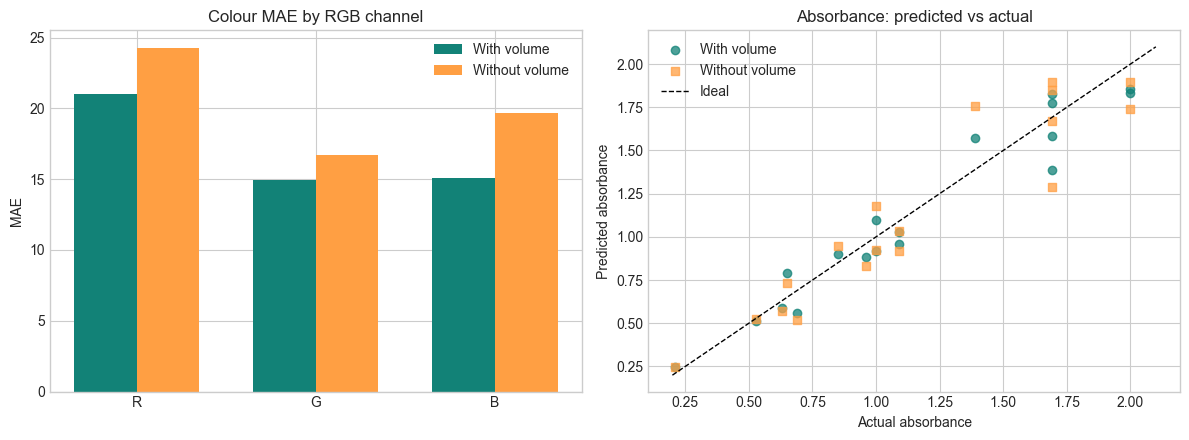

In [33]:
# Per-channel colour MAE and predicted-vs-actual absorbance scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

channels = ["R", "G", "B"]
x = np.arange(len(channels))
width = 0.35
axes[0].bar(x - width / 2, rgb_mae_channels, width, label="With volume", color="#128277")
axes[0].bar(x + width / 2, rgb_mae_channels_nv, width, label="Without volume", color="#FF9F43")
axes[0].set_xticks(x)
axes[0].set_xticklabels(channels)
axes[0].set_ylabel("MAE")
axes[0].set_title("Colour MAE by RGB channel")
axes[0].legend()

axes[1].scatter(y_abs_test, abs_pred, alpha=0.75, label="With volume", color="#128277")
axes[1].scatter(y_abs_test_nv, abs_pred_nv, alpha=0.75, marker="s", label="Without volume", color="#FF9F43")
lims = [
    min(y_abs_test.min(), abs_pred.min(), abs_pred_nv.min()) * 0.95,
    max(y_abs_test.max(), abs_pred.max(), abs_pred_nv.max()) * 1.05,
]
axes[1].plot(lims, lims, "k--", linewidth=1, label="Ideal")
axes[1].set_xlabel("Actual absorbance")
axes[1].set_ylabel("Predicted absorbance")
axes[1].set_title("Absorbance: predicted vs actual")
axes[1].legend()

fig.tight_layout()
plt.show()


## Multi-model experiment (with vs without volume)

Compare several regressors on the same train/test split:

- Linear Regression, Ridge
- k-NN, Decision Tree
- Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting
- SVR (scaled)

For each algorithm we train absorbance first, then colour using that model’s predicted absorbance (same two-stage setup as above). Metrics are reported for **with volume** (`volume_ml` + `conc`) and **without volume** (`conc` only).


In [ ]:
def make_model_zoo():
    """Fresh estimator instances for each experiment run."""
    return {
        "LinearRegression": LinearRegression(),
        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),
        "kNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor(n_neighbors=5)),
        ]),
        "DecisionTree": DecisionTreeRegressor(random_state=42, min_samples_leaf=2),
        "RandomForest": RandomForestRegressor(
            n_estimators=400, random_state=42, min_samples_leaf=2
        ),
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=400, random_state=42, min_samples_leaf=2
        ),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
        "SVR": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(C=10.0, epsilon=0.05)),
        ]),
    }


def regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }


def evaluate_model_zoo(X_train, X_test, y_abs_train, y_abs_test, y_rgb_train, y_rgb_test, volume_setting):
    rows = []
    for name, abs_estimator in make_model_zoo().items():
        abs_estimator.fit(X_train, y_abs_train)
        abs_pred_test = abs_estimator.predict(X_test)
        abs_metrics = regression_metrics(y_abs_test, abs_pred_test)

        train_abs_hat = abs_estimator.predict(X_train)
        test_abs_hat = abs_pred_test
        X_rgb_train = X_train.copy().assign(abs_pred=train_abs_hat)
        X_rgb_test = X_test.copy().assign(abs_pred=test_abs_hat)

        colour_base = make_model_zoo()[name]
        rgb_estimator = MultiOutputRegressor(colour_base)
        rgb_estimator.fit(X_rgb_train, y_rgb_train)
        rgb_pred_test = rgb_estimator.predict(X_rgb_test)
        rgb_metrics = regression_metrics(y_rgb_test, rgb_pred_test)

        rows.append({
            "algorithm": name,
            "volume": volume_setting,
            "target": "Absorbance",
            **abs_metrics,
        })
        rows.append({
            "algorithm": name,
            "volume": volume_setting,
            "target": "Colour (RGB)",
            **rgb_metrics,
        })
        print(f"{name:22s} | {volume_setting:15s} | abs R2={abs_metrics['R2']:.4f} | rgb R2={rgb_metrics['R2']:.4f}")

    return pd.DataFrame(rows)


y_abs_all = clean["abs"]
y_rgb_all = clean[["r", "g", "b"]]

X_with = clean[["volume_ml", "conc"]]
X_without = clean[["conc"]]

Xw_train, Xw_test, ya_train, ya_test, yr_train, yr_test = train_test_split(
    X_with, y_abs_all, y_rgb_all, test_size=0.2, random_state=42
)
Xo_train, Xo_test, _, _, _, _ = train_test_split(
    X_without, y_abs_all, y_rgb_all, test_size=0.2, random_state=42
)

print("Running multi-model experiment...\n")
results_with = evaluate_model_zoo(
    Xw_train, Xw_test, ya_train, ya_test, yr_train, yr_test, "With volume"
)
results_without = evaluate_model_zoo(
    Xo_train, Xo_test, ya_train, ya_test, yr_train, yr_test, "Without volume"
)

model_comparison = pd.concat([results_with, results_without], ignore_index=True)
model_comparison


In [ ]:
abs_r2 = model_comparison.query("target == 'Absorbance'").pivot(
    index="algorithm", columns="volume", values="R2"
).sort_values("With volume", ascending=False)
abs_mae = model_comparison.query("target == 'Absorbance'").pivot(
    index="algorithm", columns="volume", values="MAE"
).sort_values("With volume")
rgb_r2 = model_comparison.query("target == 'Colour (RGB)'").pivot(
    index="algorithm", columns="volume", values="R2"
).sort_values("With volume", ascending=False)
rgb_mae = model_comparison.query("target == 'Colour (RGB)'").pivot(
    index="algorithm", columns="volume", values="MAE"
).sort_values("With volume")

print("Absorbance R2 (higher better)")
display(abs_r2.round(4))
print("Absorbance MAE (lower better)")
display(abs_mae.round(4))
print("Colour R2 (higher better)")
display(rgb_r2.round(4))
print("Colour MAE (lower better)")
display(rgb_mae.round(4))

abs_r2_delta = (abs_r2["With volume"] - abs_r2["Without volume"]).sort_values(ascending=False)
rgb_r2_delta = (rgb_r2["With volume"] - rgb_r2["Without volume"]).sort_values(ascending=False)
print("\nAbsorbance R2 gain from including volume:")
display(abs_r2_delta.round(4).to_frame("R2_with_minus_without"))
print("Colour R2 gain from including volume:")
display(rgb_r2_delta.round(4).to_frame("R2_with_minus_without"))


In [ ]:
algorithms = sorted(model_comparison["algorithm"].unique())
x = np.arange(len(algorithms))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 9))


def grouped_metric(ax, target, metric, title):
    sub = model_comparison.query("target == @target")
    with_vals = [
        sub.loc[(sub["algorithm"] == a) & (sub["volume"] == "With volume"), metric].iloc[0]
        for a in algorithms
    ]
    without_vals = [
        sub.loc[(sub["algorithm"] == a) & (sub["volume"] == "Without volume"), metric].iloc[0]
        for a in algorithms
    ]
    ax.bar(x - width / 2, with_vals, width, label="With volume", color="#128277")
    ax.bar(x + width / 2, without_vals, width, label="Without volume", color="#FF9F43")
    ax.set_xticks(x)
    ax.set_xticklabels(algorithms, rotation=35, ha="right")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=8)


grouped_metric(axes[0, 0], "Absorbance", "R2", "Absorbance R2 (higher better)")
grouped_metric(axes[0, 1], "Absorbance", "MAE", "Absorbance MAE (lower better)")
grouped_metric(axes[1, 0], "Colour (RGB)", "R2", "Colour R2 (higher better)")
grouped_metric(axes[1, 1], "Colour (RGB)", "MAE", "Colour MAE (lower better)")

fig.suptitle("Multi-model comparison: with volume vs without volume", fontsize=14)
fig.tight_layout()
plt.show()

best_abs_with = (
    model_comparison.query("target == 'Absorbance' and volume == 'With volume'")
    .sort_values("R2", ascending=False)
    .iloc[0]
)
best_abs_without = (
    model_comparison.query("target == 'Absorbance' and volume == 'Without volume'")
    .sort_values("R2", ascending=False)
    .iloc[0]
)
best_rgb_with = (
    model_comparison.query("target == 'Colour (RGB)' and volume == 'With volume'")
    .sort_values("R2", ascending=False)
    .iloc[0]
)
best_rgb_without = (
    model_comparison.query("target == 'Colour (RGB)' and volume == 'Without volume'")
    .sort_values("R2", ascending=False)
    .iloc[0]
)

print("Best by R2")
print(
    f"  Absorbance + volume   : {best_abs_with['algorithm']} "
    f"(R2={best_abs_with['R2']:.4f}, MAE={best_abs_with['MAE']:.4f})"
)
print(
    f"  Absorbance no volume  : {best_abs_without['algorithm']} "
    f"(R2={best_abs_without['R2']:.4f}, MAE={best_abs_without['MAE']:.4f})"
)
print(
    f"  Colour + volume       : {best_rgb_with['algorithm']} "
    f"(R2={best_rgb_with['R2']:.4f}, MAE={best_rgb_with['MAE']:.4f})"
)
print(
    f"  Colour no volume      : {best_rgb_without['algorithm']} "
    f"(R2={best_rgb_without['R2']:.4f}, MAE={best_rgb_without['MAE']:.4f})"
)

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
model_comparison.to_csv(ARTIFACT_DIR / "multi_model_comparison.csv", index=False)
fig.savefig(ARTIFACT_DIR / "multi_model_comparison.png", dpi=140, bbox_inches="tight")
print("\nSaved:", ARTIFACT_DIR / "multi_model_comparison.csv")
print("Saved:", ARTIFACT_DIR / "multi_model_comparison.png")


In [34]:
def predict_sample_no_volume(concentration):
    sample = pd.DataFrame({"conc": [concentration]})
    predicted_abs = float(abs_model_no_vol.predict(sample)[0])
    sample_color = sample.assign(abs_pred=[predicted_abs])
    predicted_rgb = np.rint(np.clip(rgb_model_no_vol.predict(sample_color)[0], 0, 255)).astype(int)
    predicted_hex = rgb_to_hex(predicted_rgb)
    return {
        "concentration": float(concentration),
        "predicted_absorbance": predicted_abs,
        "predicted_rgb": tuple(int(v) for v in predicted_rgb),
        "predicted_hex": predicted_hex,
    }


example_no_vol = predict_sample_no_volume(1.5)
print("Example prediction (conc=1.5, no volume):")
example_no_vol


Example prediction (conc=1.5, no volume):


{'concentration': 1.5,
 'predicted_absorbance': 0.5167042857142868,
 'predicted_rgb': (104, 184, 190),
 'predicted_hex': '#68B8BE'}

In [35]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(abs_model_no_vol, ARTIFACT_DIR / "absorbance_model_no_volume.joblib")
joblib.dump(rgb_model_no_vol, ARTIFACT_DIR / "colour_model_rgb_no_volume.joblib")
joblib.dump(
    {
        "abs_feature_cols": feature_cols_no_vol,
        "color_feature_cols": color_feature_cols_no_vol,
        "clean_rows": len(clean),
        "uses_volume": False,
    },
    ARTIFACT_DIR / "model_metadata_no_volume.joblib",
)

print("Saved no-volume models to:", ARTIFACT_DIR.resolve())
print("  - absorbance_model_no_volume.joblib")
print("  - colour_model_rgb_no_volume.joblib")
print("  - model_metadata_no_volume.joblib")


Saved no-volume models to: C:\Users\Jyothi\Chemistry\artifacts
  - absorbance_model_no_volume.joblib
  - colour_model_rgb_no_volume.joblib
  - model_metadata_no_volume.joblib


## Interactive Predictor

Use the fields below to enter volume (mL) and concentration, then click **Predict** to get absorbance and colour from the trained models.

In [36]:
import ipywidgets as widgets
from IPython.display import HTML, clear_output, display

volume_input = widgets.FloatText(
    value=3.0,
    description="Volume (mL):",
    step=0.1,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="260px"),
)

conc_input = widgets.FloatText(
    value=1.5,
    description="Concentration:",
    step=0.1,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="260px"),
)

predict_button = widgets.Button(
    description="Predict",
    button_style="primary",
    icon="check",
)

prediction_output = widgets.Output()


def on_predict_click(_):
    with prediction_output:
        clear_output(wait=True)
        try:
            result = predict_sample(volume_input.value, conc_input.value)
        except NameError:
            print("Run the model-training cells first (the cell that defines predict_sample).")
            return

        swatch = result["predicted_hex"]
        display(
            HTML(
                f"<div style='margin-top:8px;width:240px;height:70px;border:1px solid #333;"
                f"background:{swatch};display:flex;align-items:center;justify-content:center;"
                f"color:white;font-weight:700;font-family:sans-serif;'>{swatch}</div>"
            )
        )
        print(f"Predicted absorbance: {result['predicted_absorbance']:.4f}")
        print(f"Predicted RGB: {result['predicted_rgb']}")
        print(f"Predicted HEX: {result['predicted_hex']}")


predict_button.on_click(on_predict_click)

ui = widgets.VBox([
    widgets.HBox([volume_input, conc_input]),
    predict_button,
    prediction_output,
])

display(ui)
on_predict_click(None)

print("If you only see text like 'VBox(...)', enable notebook widget rendering in VS Code and rerun this cell.")

If you only see text like 'VBox(...)', enable notebook widget rendering in VS Code and rerun this cell.


## Notes

- The workbook is small, so the model is intentionally simple and easy to inspect.
- Absorbance is predicted first, then the color model uses that predicted absorbance as an intermediate feature. That makes the color step closer to the actual chemistry in the sheet.
- Colour is still returned as RGB and HEX because that is a better fit for supervised regression than treating each HEX string as a separate class.
- A second model pair is trained **without volume** (`conc` only) and saved as `*_no_volume.joblib` artifacts for comparison in the Streamlit app.
- The multi-model section benchmarks several sklearn regressors with/without volume; production artifacts still use Random Forest unless you change the save cells.
